In [3]:
!apt-get install graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [4]:
import os
import time
import graphviz
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/Trabalho_Arvores/Splay'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Pasta de destino pronta em: {OUTPUT_DIR}")

Mounted at /content/drive
Pasta de destino pronta em: /content/drive/MyDrive/Trabalho_Arvores/Splay


In [5]:
class SplayNode:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class SplayTreeInstrumentada:
    def __init__(self):
        self.root = None
        self.comparisons_count = 0
        self.rotations_count = 0
        self.nodes_count = 0

    def reset_metrics(self):
        self.comparisons_count = 0
        self.rotations_count = 0

    def _right_rotate(self, x):
        self.rotations_count += 1
        y = x.left
        x.left = y.right
        y.right = x
        return y

    def _left_rotate(self, x):
        self.rotations_count += 1
        y = x.right
        x.right = y.left
        y.left = x
        return y

    def _splay(self, root, key):
        if root is None or root.key == key:
            return root

        self.comparisons_count += 1
        if key < root.key:
            if root.left is None:
                return root
            self.comparisons_count += 1
            if key < root.left.key:
                root.left.left = self._splay(root.left.left, key)
                root = self._right_rotate(root)
            elif key > root.left.key:
                root.left.right = self._splay(root.left.right, key)
                if root.left.right is not None:
                    root.left = self._left_rotate(root.left)

            return root if root.left is None else self._right_rotate(root)
        else:
            if root.right is None:
                return root
            self.comparisons_count += 1
            if key < root.right.key:
                root.right.left = self._splay(root.right.left, key)
                if root.right.left is not None:
                    root.right = self._right_rotate(root.right)
            elif key > root.right.key:
                root.right.right = self._splay(root.right.right, key)
                root = self._left_rotate(root)

            return root if root.right is None else self._left_rotate(root)

    def insert(self, key):
        if self.root is None:
            self.root = SplayNode(key)
            self.nodes_count += 1
            return

        self.root = self._splay(self.root, key)

        if self.root.key == key:
            return

        new_node = SplayNode(key)
        self.nodes_count += 1
        if key < self.root.key:
            new_node.right = self.root
            new_node.left = self.root.left
            self.root.left = None
        else:
            new_node.left = self.root
            new_node.right = self.root.right
            self.root.right = None

        self.root = new_node

    def search(self, key):
        self.root = self._splay(self.root, key)
        if self.root and self.root.key == key:
            return True
        return False

    def delete(self, key):
        if self.root is None:
            return

        self.root = self._splay(self.root, key)

        if key != self.root.key:
            return

        if self.root.left is None:
            self.root = self.root.right
        else:
            temp = self.root.right
            self.root = self.root.left
            self.root = self._splay(self.root, key)
            self.root.right = temp
        self.nodes_count -= 1

    def save_diagram(self, filename: str, directory: str = OUTPUT_DIR):
        dot = graphviz.Digraph(comment='Splay Tree')

        def _add_edges(node):
            if node:
                if node.left:
                    dot.edge(str(node.key), str(node.left.key), label="L")
                    _add_edges(node.left)
                if node.right:
                    dot.edge(str(node.key), str(node.right.key), label="R")
                    _add_edges(node.right)

        if self.root:
            dot.node(str(self.root.key), f"ROOT: {self.root.key}", color="red", style="filled", fillcolor="lightblue")
            _add_edges(self.root)

        filepath = dot.render(filename=filename, directory=directory, format='png', cleanup=True)
        print(f"Diagrama Splay salvo em: {filepath}")
        return dot

Diagrama Splay salvo em: /content/drive/MyDrive/Trabalho_Arvores/Splay/splay_teste.png


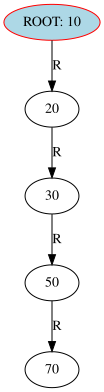

In [6]:
splay = SplayTreeInstrumentada()
for val in [50, 20, 70, 10, 30]:
    splay.insert(val)

splay.search(10)

dot_splay = splay.save_diagram("splay_teste", directory=OUTPUT_DIR)
display(dot_splay)